# El HIV necesita *tocar* células para infectarlas

**3,6 veces** más infección por contacto célula-célula que por virus libre. La diferencia: una señal que cruza el receptor CD4 y abre el poro nuclear.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-hiv-poros-nucleares-infeccion/notebook.ipynb)

**Paper:** [HIV-1 signalling remodels nuclear pores to licence infection](https://doi.org/10.1038/s41586-026-10453-3) · Nature, 2026-05-06

**Datos:** Source Data Figuras 1, 3 y 4 ([MOESM7](https://doi.org/10.1038/s41586-026-10453-3), [MOESM9](https://doi.org/10.1038/s41586-026-10453-3), [MOESM10](https://doi.org/10.1038/s41586-026-10453-3))

**Video corto:** [Pendiente]

## El acertijo

En personas con VIH, el virus se encuentra en linfocitos T CD4+ en reposo —las células que duermen, listas a despertarse cuando llega un patógeno—. Pero en el laboratorio, ese mismo virus suspendido en medio de cultivo no logra infectarlas. Algo del cuerpo está activando un permiso que el virus libre no consigue.

El permiso es **el contacto físico** entre una célula infectada y una sana. Y rastrearon la señal hasta el poro del núcleo: una quinasa llamada CDK1 que termina fosforilando tres proteínas específicas del canal central del poro nuclear, abriéndolo para que la cápside viral pueda entrar.

Aquí abrimos los tres datasets clave del paper y verificamos qué tan sólido es cada paso de esta cascada.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RATIO_OBSERVADO = 3.63           # cell-cell / cell-free (veces más infección)
CDK1_REDUCCION_PCT = 33.0        # % de bajada en CDK1 knockdown vs NTC
NUP54_DELTA_PCT = 32.0           # incremento medio de Nup54 fosforilado (+VS vs -VS)

FUENTE = 'Fuente: Mesner et al. (2026), Nature | Source Data Figs. 1, 3, 4'

COLOR_DATOS = '#2563EB'          # azul CaM
COLOR_ALERTA = '#DC2626'         # rojo — contraste
COLOR_REFERENCIA = '#D97706'     # ámbar — umbral
COLOR_SEC = '#059669'            # emerald — secundario
COLOR_GRIS = '#BBBBBB'           # contexto

import os, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local primero, GitHub raw como fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Cargar datasets
df_cf = pd.read_csv('datos/cellfree_vs_cellcell.csv')
df_kd = pd.read_csv('datos/knockdown_cdk1.csv')
df_nup = pd.read_csv('datos/nup_phosphorylation.csv')

os.makedirs('figuras', exist_ok=True)

print(f'Cell-free vs cell-cell: {len(df_cf)} donantes')
print(df_cf.to_string(index=False))
print()
print(f'CDK1 knockdown: {len(df_kd)} donantes × 3 condiciones')
print(df_kd.to_string(index=False))
print()
print(f'Fosforilación de nucleoporinas: {len(df_nup)} mediciones')
print(f'  Nucleoporinas: {df_nup["nup"].nunique()}  ·  Condiciones: {list(df_nup["condicion"].unique())}')

Cell-free vs cell-cell: 3 donantes
donante  cell_free_pct  cell_cell_pct
     D1            2.4           10.9
     D2            4.1           14.0
     D3            2.9            9.2

CDK1 knockdown: 3 donantes × 3 condiciones
donante  untreated  non_targeting_ctrl  cdk1_knockdown
     D1       2045                2172            1632
     D2       2339                2296            1434
     D3       2138                2462            1578

Fosforilación de nucleoporinas: 978 mediciones
  Nucleoporinas: 10  ·  Condiciones: ['-VS', '+VS']


## Aquí está.

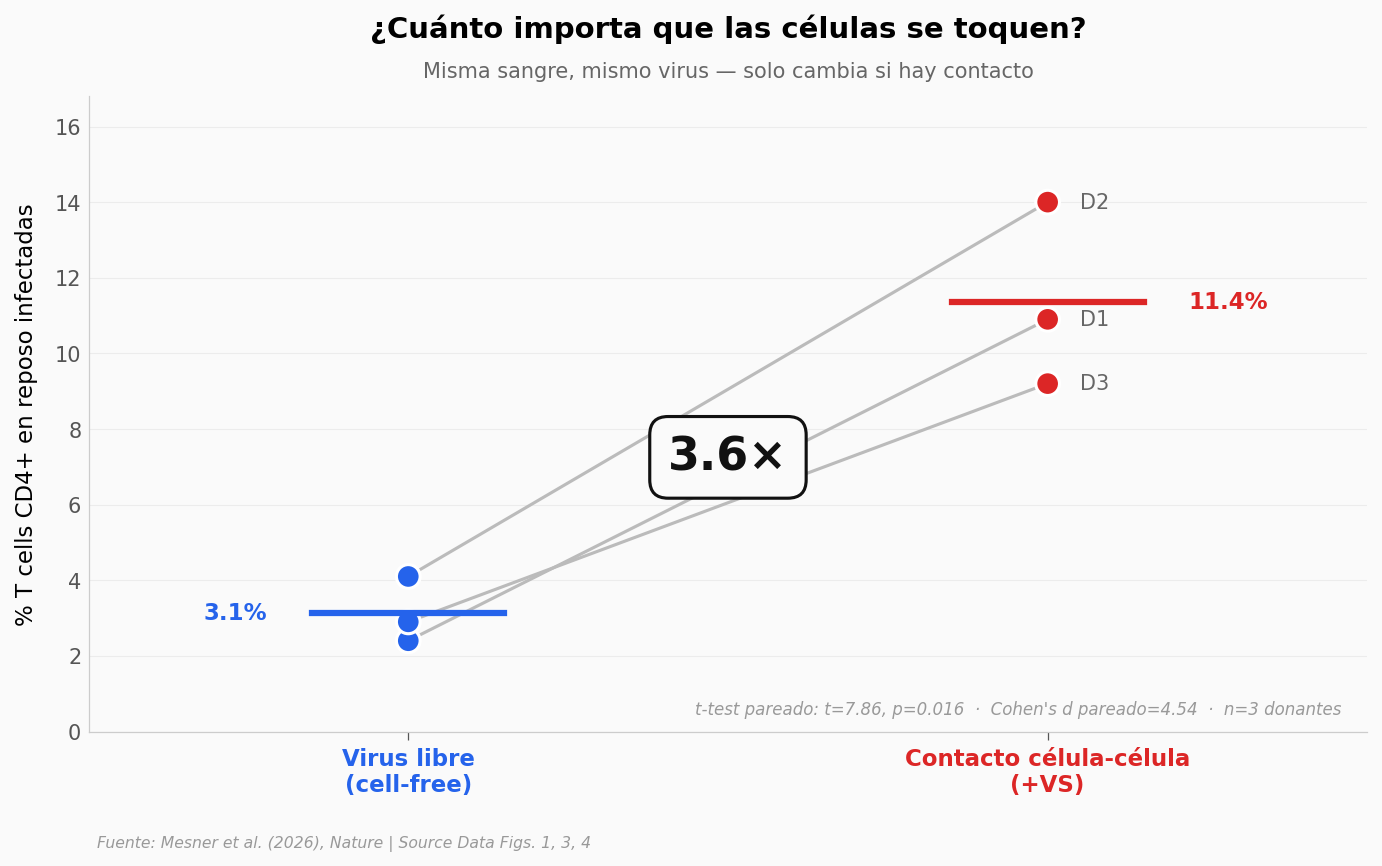

In [2]:
# Hero — cell-free vs cell-cell pareado por donante
fig, ax = plt.subplots(figsize=(11, 5.5))

# Datos por donante: dos puntos conectados (free → cell)
donantes = df_cf['donante'].tolist()
free_vals = df_cf['cell_free_pct'].values
cell_vals = df_cf['cell_cell_pct'].values

x_free, x_cell = 0, 1
for i, (f, c, d) in enumerate(zip(free_vals, cell_vals, donantes)):
    ax.plot([x_free, x_cell], [f, c], color=COLOR_GRIS, linewidth=1.5, zorder=2)
    ax.scatter([x_free, x_cell], [f, c], color=[COLOR_DATOS, COLOR_ALERTA],
               s=130, edgecolors='white', linewidths=1.5, zorder=5)
    # etiqueta del donante a la derecha
    ax.text(x_cell + 0.05, c, d, fontsize=10, color='#666666', va='center')

# Medias como barras horizontales
mean_free = free_vals.mean()
mean_cell = cell_vals.mean()
ax.plot([x_free - 0.15, x_free + 0.15], [mean_free, mean_free],
        color=COLOR_DATOS, linewidth=3, zorder=6)
ax.plot([x_cell - 0.15, x_cell + 0.15], [mean_cell, mean_cell],
        color=COLOR_ALERTA, linewidth=3, zorder=6)

# Etiquetas de medias
ax.text(x_free - 0.22, mean_free, f'{mean_free:.1f}%', fontsize=11,
        fontweight='bold', color=COLOR_DATOS, ha='right', va='center')
ax.text(x_cell + 0.22, mean_cell, f'{mean_cell:.1f}%', fontsize=11,
        fontweight='bold', color=COLOR_ALERTA, ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

# Anotación del ratio
ratio = mean_cell / mean_free
ax.annotate(f'{ratio:.1f}×', xy=(0.5, (mean_free + mean_cell) / 2),
            fontsize=22, fontweight='bold', color='#111111',
            ha='center', va='center',
            bbox=dict(facecolor='#FAFAFA', edgecolor='#111111', linewidth=1.5,
                      boxstyle='round,pad=0.4'))

ax.set_xticks([x_free, x_cell])
ax.set_xticklabels(['Virus libre\n(cell-free)', 'Contacto célula-célula\n(+VS)'],
                   fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_DATOS, COLOR_ALERTA]):
    tick.set_color(color)

ax.set_ylabel('% T cells CD4+ en reposo infectadas', fontsize=11)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, max(cell_vals) * 1.2)

ax.set_title('¿Cuánto importa que las células se toquen?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Misma sangre, mismo virus — solo cambia si hay contacto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# t-test pareado
diffs = cell_vals - free_vals
t_stat, p_val = stats.ttest_rel(cell_vals, free_vals)
d_pareado = diffs.mean() / diffs.std(ddof=1)
ax.text(0.98, 0.02,
        f't-test pareado: t={t_stat:.2f}, p={p_val:.3f}  ·  Cohen\'s d pareado={d_pareado:.2f}  ·  n=3 donantes',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_cellfree_vs_cellcell.png', dpi=200, bbox_inches='tight')
plt.show()

Tres donantes humanos. Para cada uno, sangre dividida en dos: una parte expuesta al virus libre, otra puesta en contacto con células ya infectadas. La línea gris une los dos puntos del mismo donante.

El patrón se repite en los tres: el contacto **multiplica la infección por 3,6**. Y no es ruido — la diferencia se mantiene grande aun cuando los donantes parten de niveles distintos (D1 sube de 2,4% a 10,9%; D2 de 4,1% a 14%). Eso es lo que cuenta cuando la muestra es pequeña: que cada réplica se mueva en la misma dirección.

El siguiente paso del paper es preguntarse **qué hace el contacto que el virus libre no logra**.

## Una quinasa en el medio

Sigamos la señal que se activa cuando las células se tocan. El contacto enciende el receptor CD4, ese receptor enciende la quinasa LCK (otra quinasa, aguas arriba), y LCK termina activando una vieja conocida del ciclo celular: **CDK1**.

Para probar que CDK1 era necesaria, silenciaron su gen con un siRNA (knockdown) y midieron la infección. Si CDK1 importa, silenciarla debería bajar la entrada del virus.

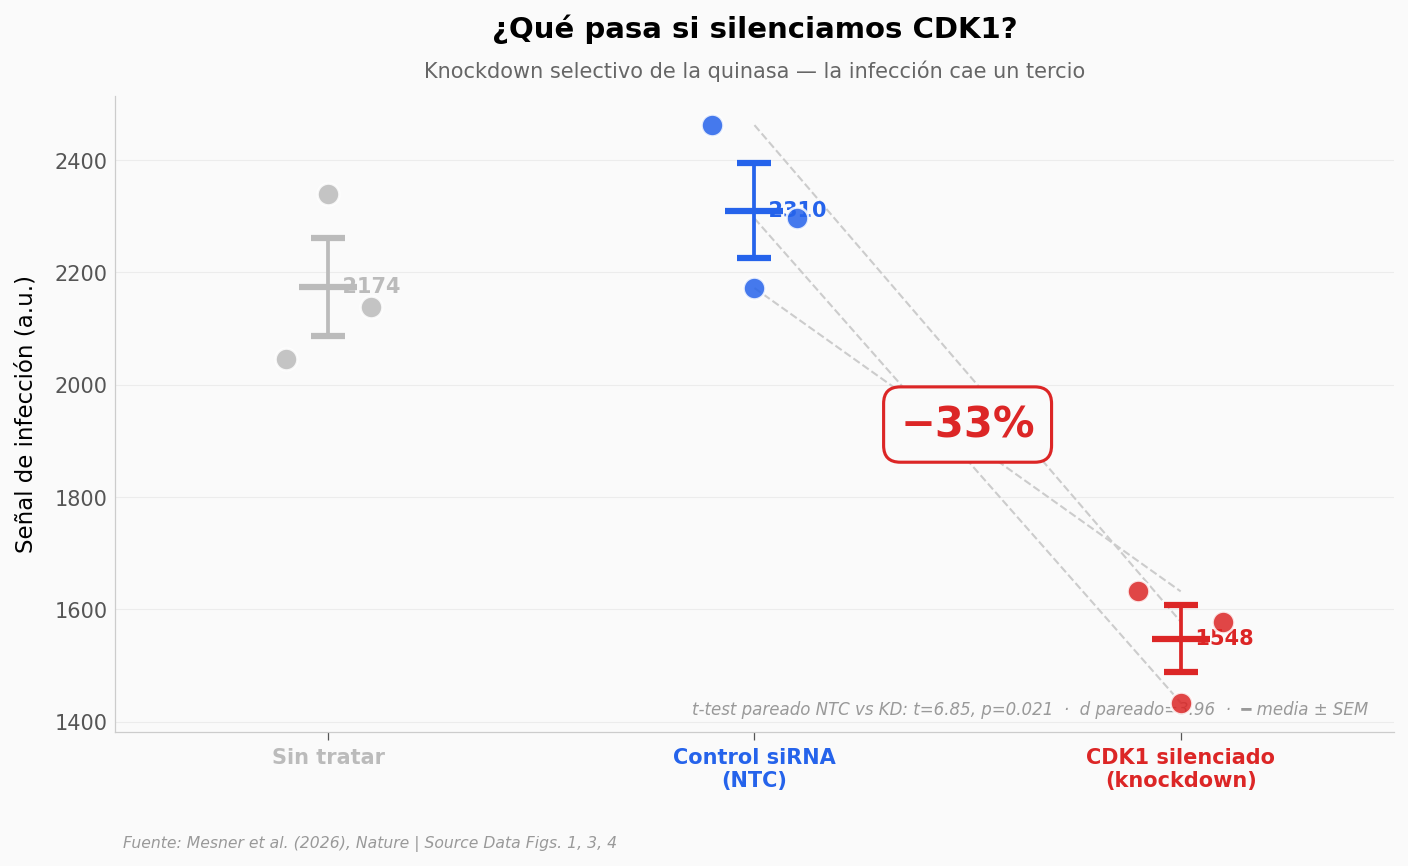

In [3]:
# CDK1 knockdown: 3 condiciones × 3 donantes
fig, ax = plt.subplots(figsize=(11, 5.5))

condiciones = ['Sin tratar', 'Control siRNA\n(NTC)', 'CDK1 silenciado\n(knockdown)']
cols = ['untreated', 'non_targeting_ctrl', 'cdk1_knockdown']
colores = [COLOR_GRIS, COLOR_DATOS, COLOR_ALERTA]
positions = [0, 1, 2]

np.random.seed(42)
for i, (col, color, pos) in enumerate(zip(cols, colores, positions)):
    vals = df_kd[col].values
    n = len(vals)
    x_strip = np.linspace(pos - 0.10, pos + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=110, alpha=0.85,
               edgecolors='white', linewidths=1.2, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3,
                capsize=8, capthick=1.5, zorder=6)
    ax.text(pos, mean, f'  {mean:.0f}', fontsize=10, fontweight='bold',
            color=color, va='center', ha='left',
            transform=ax.transData)

# Líneas pareadas entre NTC y KD por donante
for donante in df_kd['donante']:
    row = df_kd[df_kd['donante'] == donante].iloc[0]
    ax.plot([1, 2], [row['non_targeting_ctrl'], row['cdk1_knockdown']],
            color='#CCCCCC', linewidth=1, zorder=2, linestyle='--')

# Anotación de la caída
ntc_mean = df_kd['non_targeting_ctrl'].mean()
kd_mean = df_kd['cdk1_knockdown'].mean()
reduccion_pct = (ntc_mean - kd_mean) / ntc_mean * 100
ax.annotate(f'−{reduccion_pct:.0f}%',
            xy=(1.5, (ntc_mean + kd_mean) / 2),
            fontsize=20, fontweight='bold', color=COLOR_ALERTA,
            ha='center', va='center',
            bbox=dict(facecolor='#FAFAFA', edgecolor=COLOR_ALERTA,
                      linewidth=1.5, boxstyle='round,pad=0.4'))

ax.set_xticks(positions)
ax.set_xticklabels(condiciones, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores):
    tick.set_color(color)

ax.set_ylabel('Señal de infección (a.u.)', fontsize=11)
ax.set_xlim(-0.5, 2.5)

ax.set_title('¿Qué pasa si silenciamos CDK1?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Knockdown selectivo de la quinasa — la infección cae un tercio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Test pareado NTC vs KD
ntc = df_kd['non_targeting_ctrl'].values
kd = df_kd['cdk1_knockdown'].values
diffs_kd = ntc - kd
t_kd, p_kd = stats.ttest_rel(ntc, kd)
d_kd = diffs_kd.mean() / diffs_kd.std(ddof=1)

ax.text(0.98, 0.02,
        f't-test pareado NTC vs KD: t={t_kd:.2f}, p={p_kd:.3f}  ·  d pareado={d_kd:.2f}  ·  ━ media ± SEM',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cdk1_knockdown.png', dpi=200, bbox_inches='tight')
plt.show()

## El poro nuclear, vigilado por una quinasa

Hasta aquí, dos eslabones: el contacto sube la infección, y CDK1 es necesaria. Falta la última pregunta: **¿qué hace CDK1 que abre la puerta al virus?**

Aquí se midió la fosforilación de diez nucleoporinas —las proteínas que forman el poro nuclear, esa rosca por donde tienen que pasar la cápside y todo lo que entra al núcleo—. Compararon células con contacto (+VS) y sin contacto (-VS), con ~50 mediciones por proteína por condición.

Si CDK1 marcase el poro completo, las diez subirían en +VS. Si actúa selectivamente, solo unas pocas.

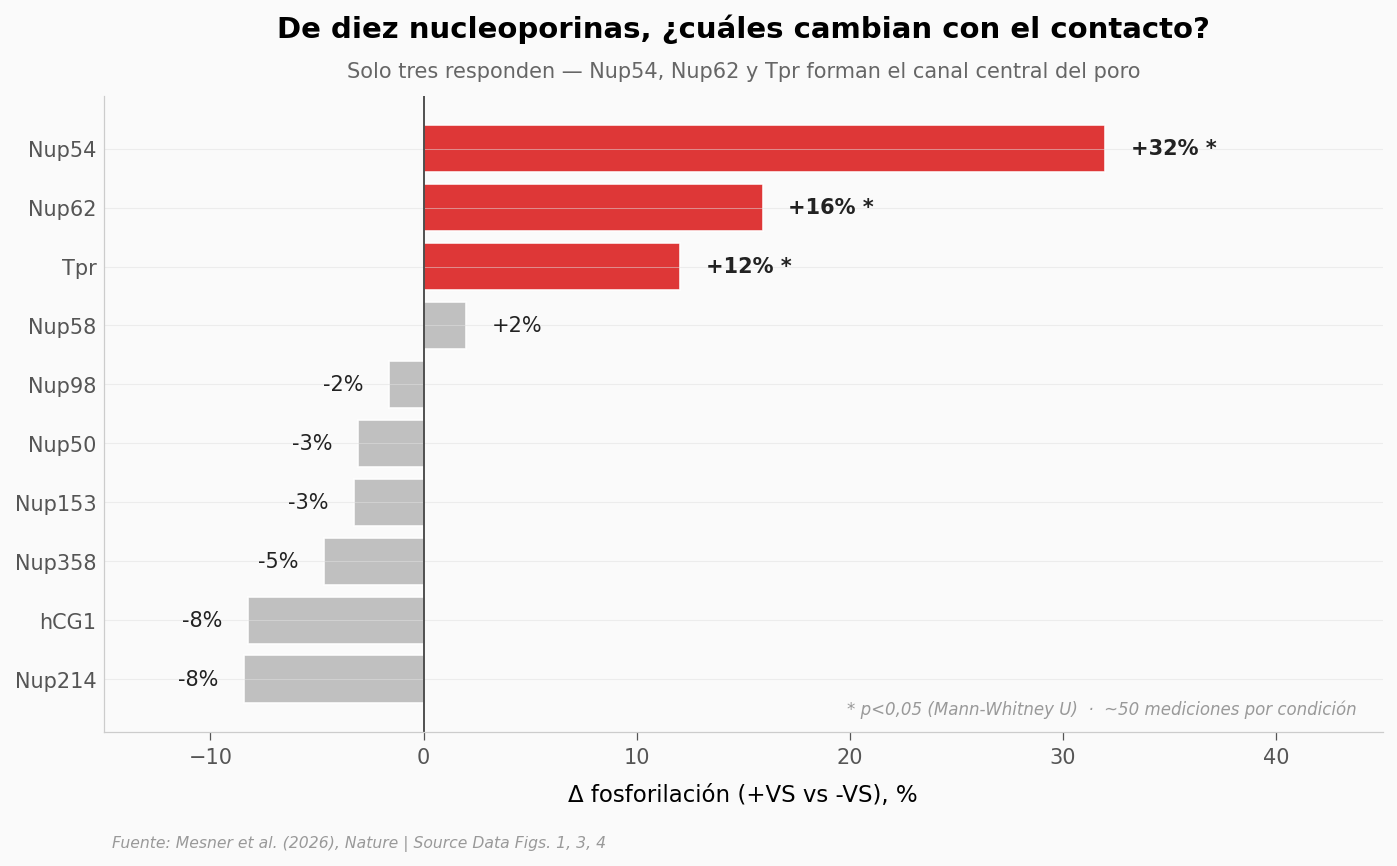

Resumen por nucleoporina (orden descendente por |Δ|):
   nup  delta_pct         d        p
 Nup54  31.992330  0.710514 0.001098
 Nup62  15.915661  0.624661 0.004223
   Tpr  12.035788  1.011829 0.000008
Nup214  -8.436725 -0.302842 0.156562
  hCG1  -8.259323 -0.222302 0.299488
Nup358  -4.651479 -0.169038 0.412001
Nup153  -3.258810 -0.301868 0.096622
 Nup50  -3.088195 -0.142791 0.612727
 Nup58   2.010196  0.060858 0.803995
 Nup98  -1.606161 -0.044750 0.801327


In [4]:
# Δ% de fosforilación por nucleoporina (+VS vs -VS)
fig, ax = plt.subplots(figsize=(11, 5.5))

# Calcular delta por nucleoporina con test Mann-Whitney
resultados = []
for nup in df_nup['nup'].unique():
    vals_minus = df_nup[(df_nup['nup'] == nup) & (df_nup['condicion'] == '-VS')]['intensidad_relativa'].values
    vals_plus = df_nup[(df_nup['nup'] == nup) & (df_nup['condicion'] == '+VS')]['intensidad_relativa'].values
    mean_minus = vals_minus.mean()
    mean_plus = vals_plus.mean()
    delta_pct = (mean_plus - mean_minus) / mean_minus * 100
    u, p = stats.mannwhitneyu(vals_plus, vals_minus, alternative='two-sided')
    pooled_std = np.sqrt((vals_plus.var(ddof=1) + vals_minus.var(ddof=1)) / 2)
    d = (mean_plus - mean_minus) / pooled_std
    resultados.append({'nup': nup, 'delta_pct': delta_pct, 'p': p, 'd': d,
                       'n_plus': len(vals_plus), 'n_minus': len(vals_minus)})

df_res = pd.DataFrame(resultados).sort_values('delta_pct', ascending=True).reset_index(drop=True)

# Colores: significativos (p<0.05 Y delta>5%) en rojo/azul según signo, resto gris
def color_para(row):
    if row['p'] < 0.05 and abs(row['delta_pct']) > 5:
        return COLOR_ALERTA if row['delta_pct'] > 0 else COLOR_DATOS
    return COLOR_GRIS

colores = [color_para(r) for _, r in df_res.iterrows()]

bars = ax.barh(df_res['nup'], df_res['delta_pct'], color=colores,
               edgecolor='white', linewidth=0.8, alpha=0.92)
ax.axvline(x=0, color='#333333', linewidth=0.8)

# Etiqueta inline con el %
for i, (bar, row) in enumerate(zip(bars, df_res.itertuples())):
    val = row.delta_pct
    x_pos = val + (1.2 if val >= 0 else -1.2)
    ha = 'left' if val >= 0 else 'right'
    label = f'{val:+.0f}%'
    if row.p < 0.05 and abs(val) > 5:
        label += ' *'
    ax.text(x_pos, i, label, fontsize=10,
            color='#222222', va='center', ha=ha,
            fontweight='bold' if row.p < 0.05 and abs(val) > 5 else 'normal')

ax.set_xlabel('Δ fosforilación (+VS vs -VS), %', fontsize=11)
ax.set_xlim(-15, 45)

ax.set_title('De diez nucleoporinas, ¿cuáles cambian con el contacto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Solo tres responden — Nup54, Nup62 y Tpr forman el canal central del poro',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota
ax.text(0.98, 0.02, '* p<0,05 (Mann-Whitney U)  ·  ~50 mediciones por condición',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/nucleoporinas_delta.png', dpi=200, bbox_inches='tight')
plt.show()

# Mostrar resumen para referencia
print('Resumen por nucleoporina (orden descendente por |Δ|):')
print(df_res.sort_values('delta_pct', key=abs, ascending=False)[['nup', 'delta_pct', 'd', 'p']].to_string(index=False))

## ¿Qué tan claro es el cambio en Nup54?

Las barras del gráfico anterior muestran medias, pero hay 50 mediciones por condición. Para ver si el efecto en Nup54 —la nucleoporina más afectada— es un cambio limpio o solo un corrimiento del promedio con mucha dispersión, vamos a mirar las dos distribuciones completas.

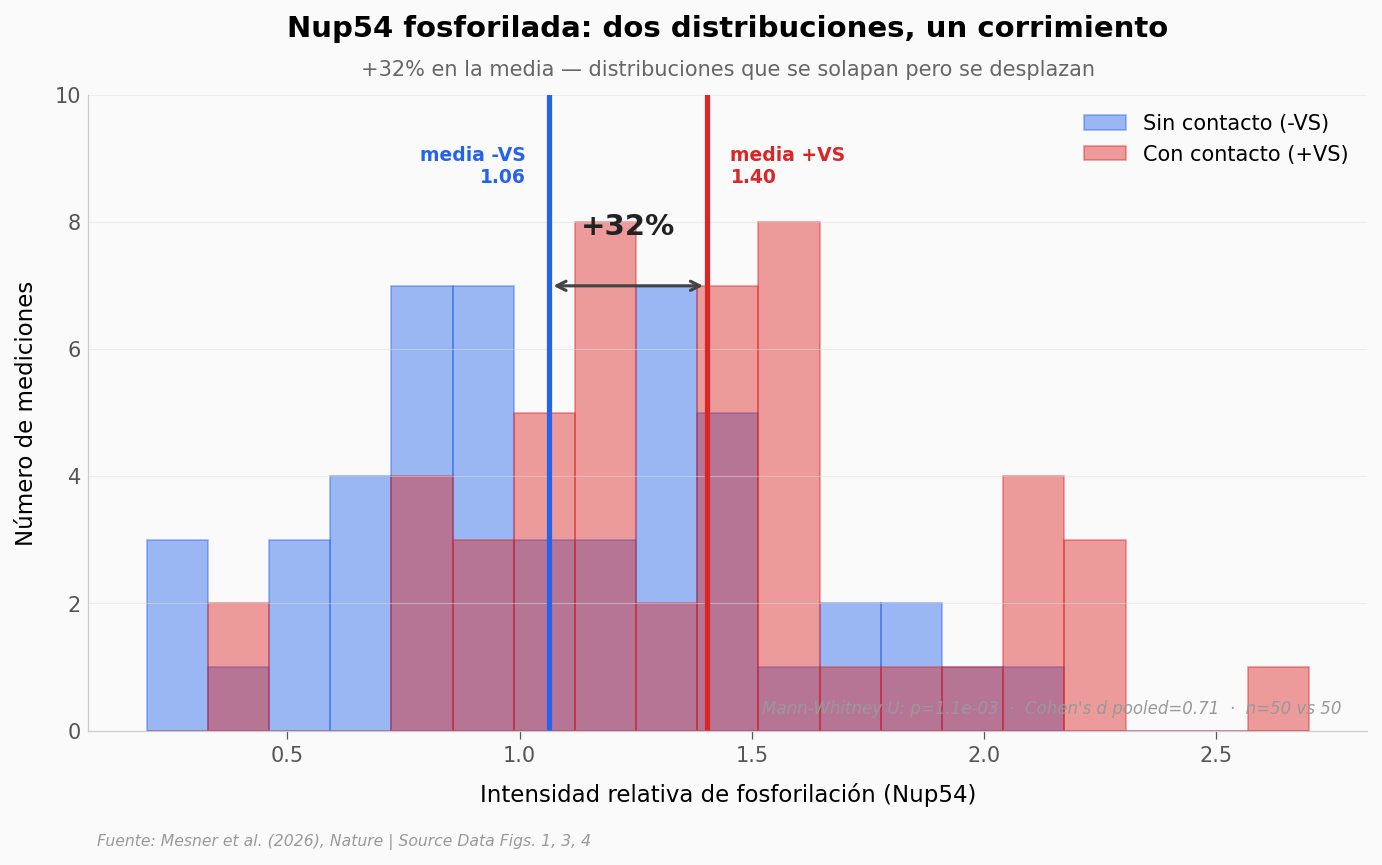

In [5]:
# Distribuciones de Nup54: -VS vs +VS
nup54_minus = df_nup[(df_nup['nup'] == 'Nup54') & (df_nup['condicion'] == '-VS')]['intensidad_relativa'].values
nup54_plus = df_nup[(df_nup['nup'] == 'Nup54') & (df_nup['condicion'] == '+VS')]['intensidad_relativa'].values

fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.linspace(
    min(nup54_minus.min(), nup54_plus.min()),
    max(nup54_minus.max(), nup54_plus.max()),
    20,
)

n1, _, _ = ax.hist(nup54_minus, bins=bins, color=COLOR_DATOS, alpha=0.45,
                   edgecolor=COLOR_DATOS, linewidth=0.8, label='Sin contacto (-VS)')
n2, _, _ = ax.hist(nup54_plus, bins=bins, color=COLOR_ALERTA, alpha=0.45,
                   edgecolor=COLOR_ALERTA, linewidth=0.8, label='Con contacto (+VS)')

y_max = max(n1.max(), n2.max()) * 1.25
ax.set_ylim(0, y_max)

# Medias verticales
m_minus, m_plus = nup54_minus.mean(), nup54_plus.mean()
ax.axvline(x=m_minus, color=COLOR_DATOS, linewidth=2.5)
ax.axvline(x=m_plus, color=COLOR_ALERTA, linewidth=2.5)

# Flecha bidireccional entre medias
ax.annotate('', xy=(m_plus, y_max * 0.7), xytext=(m_minus, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.5))
delta_pct_nup54 = (m_plus - m_minus) / m_minus * 100
ax.text((m_minus + m_plus) / 2, y_max * 0.78,
        f'+{delta_pct_nup54:.0f}%', fontsize=14, fontweight='bold',
        color='#222222', ha='center')

# Etiquetas inline
ax.text(m_minus - 0.05, y_max * 0.92, f'media -VS\n{m_minus:.2f}',
        fontsize=9, color=COLOR_DATOS, ha='right', va='top', fontweight='bold')
ax.text(m_plus + 0.05, y_max * 0.92, f'media +VS\n{m_plus:.2f}',
        fontsize=9, color=COLOR_ALERTA, ha='left', va='top', fontweight='bold')

# Tests
u_n54, p_n54 = stats.mannwhitneyu(nup54_plus, nup54_minus, alternative='two-sided')
pooled_std = np.sqrt((nup54_plus.var(ddof=1) + nup54_minus.var(ddof=1)) / 2)
d_n54 = (m_plus - m_minus) / pooled_std

ax.set_xlabel('Intensidad relativa de fosforilación (Nup54)', fontsize=11)
ax.set_ylabel('Número de mediciones', fontsize=11)

ax.set_title('Nup54 fosforilada: dos distribuciones, un corrimiento',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'+{delta_pct_nup54:.0f}% en la media — distribuciones que se solapan pero se desplazan',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

ax.text(0.98, 0.02,
        f'Mann-Whitney U: p={p_n54:.1e}  ·  Cohen\'s d pooled={d_n54:.2f}  ·  n={len(nup54_minus)} vs {len(nup54_plus)}',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/nup54_distribucion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|:---:|---|
| El contacto célula-célula multiplica por ~3,6 la infección de T cells en reposo | ✅ | Media 11,4% (+VS) vs 3,1% (cell-free). t-test pareado p=0,016, Cohen's d pareado = 4,5. Los 3 donantes se mueven en la misma dirección. |
| CDK1 es necesaria para esta entrada nuclear | ✅ | Silenciar CDK1 reduce ~33% la señal de infección vs control siRNA. t-test pareado p=0,021, d pareado = 4,0. |
| La señal CDK1 fosforila nucleoporinas selectivamente | ✅ | De 10 nucleoporinas medidas, 3 cambian significativamente con el contacto: Nup54 (+32%), Nup62 (+16%) y Tpr (+12%). Las otras 7 (Nup358, Nup214, Nup98, Nup58, Nup153, Nup50, hCG1) no se mueven. |
| La cascada completa es CD4 → LCK → CDK1 → fosforilación de Nup | ⚠️ | Los datos del Source Data confirman dos eslabones: CDK1 necesaria, y CDK1 fosforila Nup54/62/Tpr. La activación de LCK por contacto está en figuras del paper que no entran en el Source Data — la apoyamos con la interpretación del paper, no con los CSVs disponibles. |

> **Limitaciones:**
> - n = 3 donantes humanos en las figuras 1 y 3. Tamaños del efecto enormes (d > 3,9), pero la potencia estadística es baja por la muestra pequeña — los p-valores quedan al borde de la significancia (0,016 y 0,021).
> - La fosforilación se midió por inmunofluorescencia (intensidad relativa, ratio +VS/-VS), no por western blot cuantitativo. Sirve para detectar cambios relativos entre condiciones, no para cuantificar moléculas absolutas.
> - Los donantes son anónimos; el Source Data no desglosa por edad o sexo, así que la variabilidad inter-donante no se puede atribuir a covariables clínicas.
> - El paper propone CD4-LCK-CDK1 como la cascada completa. Los datos abiertos cubren CDK1 → Nup, pero no la activación de LCK aguas arriba — ese eslabón viene de experimentos con inhibidores de LCK en el cuerpo del paper.

## Ahora tú

Tres preguntas que se pueden responder cambiando una línea de código en la celda siguiente:

1. **¿Y si excluyo D2, que tiene el efecto más grande?** Recalcular el ratio y el Cohen's d sin ese donante — ¿el patrón sobrevive?
2. **¿Cuál es la nucleoporina con el segundo efecto más grande?** Ordenar `df_res` por `d` (no por `delta_pct`) — ¿coinciden los rankings?
3. **¿Qué tan solapadas están las distribuciones de Tpr (+VS vs -VS)?** Cambiar `Nup54` por `Tpr` en la celda 11 y ver si el corrimiento es tan limpio.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ratio sin D2 (el donante con mayor efecto)
df_sin_d2 = df_cf[df_cf['donante'] != 'D2']
ratio_sin_d2 = df_sin_d2['cell_cell_pct'].mean() / df_sin_d2['cell_free_pct'].mean()
diffs_sin_d2 = df_sin_d2['cell_cell_pct'].values - df_sin_d2['cell_free_pct'].values
d_sin_d2 = diffs_sin_d2.mean() / diffs_sin_d2.std(ddof=1) if len(diffs_sin_d2) > 1 else float('nan')

print(f'Con los 3 donantes:  ratio = {df_cf["cell_cell_pct"].mean()/df_cf["cell_free_pct"].mean():.2f}×')
print(f'Sin D2 (n=2):        ratio = {ratio_sin_d2:.2f}×, d pareado = {d_sin_d2:.2f}')
print()

# Pregunta 2: orden por d (tamaño del efecto) vs orden por delta_pct
print('Top 5 por |Δ%|:')
print(df_res.sort_values('delta_pct', key=abs, ascending=False).head(5)[['nup', 'delta_pct', 'd']].to_string(index=False))
print()
print('Top 5 por |d|:')
print(df_res.sort_values('d', key=abs, ascending=False).head(5)[['nup', 'delta_pct', 'd']].to_string(index=False))

Con los 3 donantes:  ratio = 3.63×
Sin D2 (n=2):        ratio = 3.79×, d pareado = 4.76

Top 5 por |Δ%|:
   nup  delta_pct         d
 Nup54  31.992330  0.710514
 Nup62  15.915661  0.624661
   Tpr  12.035788  1.011829
Nup214  -8.436725 -0.302842
  hCG1  -8.259323 -0.222302

Top 5 por |d|:
   nup  delta_pct         d
   Tpr  12.035788  1.011829
 Nup54  31.992330  0.710514
 Nup62  15.915661  0.624661
Nup214  -8.436725 -0.302842
Nup153  -3.258810 -0.301868


## Fuentes

## Fuentes

**Paper**: [HIV-1 signalling remodels nuclear pores to licence infection](https://doi.org/10.1038/s41586-026-10453-3)  
*Nature, 2026-05-06*

**Source Data**:
- [Source Data Figure 1 (Mesner et al. 2026) — Cell-free vs cell-cell infection of resting CD4+ T cells](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10453-3/MediaObjects/41586_2026_10453_MOESM7_ESM.xlsx)
- [Source Data Figure 3 (Mesner et al. 2026) — CDK1 knockdown effect on infection](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10453-3/MediaObjects/41586_2026_10453_MOESM9_ESM.xlsx)
- [Source Data Figure 4 (Mesner et al. 2026) — Nucleoporin phosphorylation by virological synapse contact](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10453-3/MediaObjects/41586_2026_10453_MOESM10_ESM.xlsx)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

*Lab de [Ciencia a Mordiscos](https://cienciaamordiscos.com) — divulgación científica con datos reproducibles. [Código del notebook en GitHub](https://github.com/Ciencia-a-Mordiscos/lab).*